In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import coloring
from pysat.solvers import Solver
from pysat.formula import CNF

In [3]:
node_start = 4
node_end = 50
max_color_possible = 5

In [4]:
def generate_graph(num_nodes, edge_prob=0.5, seed=32):
    return nx.erdos_renyi_graph(num_nodes, edge_prob, seed=seed)

In [5]:
def encode_graph_coloring_sat(G, k):
    cnf = CNF()
    node_vars = {}
    var_counter = 1
    for node in G.nodes():
        for color in range(1, k + 1):
            node_vars[(node, color)] = var_counter

            var_counter += 1

    for node in G.nodes():
        cnf.append([node_vars[(node, color)] for color in range(1, k + 1)])
        for c1 in range(1, k + 1):
            for c2 in range(c1 + 1, k + 1):
                cnf.append([-node_vars[(node, c1)], -node_vars[(node, c2)]])

    for u, v in G.edges():
        for color in range(1, k + 1):
            cnf.append([-node_vars[(u, color)], -node_vars[(v, color)]])
    return cnf

def get_chromatic_number_via_sat(G, max_k=8):
    for k in range(1, max_k + 1):
        cnf = encode_graph_coloring_sat(G, k)
        with Solver(name="glucose3") as solver:
            solver.append_formula(cnf)
            if solver.solve():
                return k
    return None


In [6]:
import json

qaoa_data_new = {
    "4": [3,3,3,4,3],
    "5": [4,3,4,3,3],
    "6": [4,3]
}


In [7]:

qaoa_data = {
    "4": [4,4,4,4,4],
    "5": [4,5,5,5,5],
    "6": [5,4,4,4,5],
    "7": [6,5,5,6],
    "8": [8,8,8,6,6]
}

In [8]:
def compute_qaoa_accuracy(qaoa_result, sat_chromatic_number):
    accuracies=[]

    for i in qaoa_result:
        used = i
        accuracies.append(round(min(1.0, sat_chromatic_number / used), 3))
    return accuracies


In [9]:
qaoa_accuracy = {}
sat_results = {}

for n in range(4, 9):
    G = generate_graph(n, edge_prob=0.5, seed=32)
    sat_k = get_chromatic_number_via_sat(G)
    sat_results[n] = sat_k
    qaoa_k = qaoa_data[str(n)]
    accuracy = compute_qaoa_accuracy(qaoa_k,sat_k)
    qaoa_accuracy[n] = accuracy
    print(f"{qaoa_accuracy}%")


{4: [0.75, 0.75, 0.75, 0.75, 0.75]}%
{4: [0.75, 0.75, 0.75, 0.75, 0.75], 5: [0.75, 0.6, 0.6, 0.6, 0.6]}%
{4: [0.75, 0.75, 0.75, 0.75, 0.75], 5: [0.75, 0.6, 0.6, 0.6, 0.6], 6: [0.6, 0.75, 0.75, 0.75, 0.6]}%
{4: [0.75, 0.75, 0.75, 0.75, 0.75], 5: [0.75, 0.6, 0.6, 0.6, 0.6], 6: [0.6, 0.75, 0.75, 0.75, 0.6], 7: [0.5, 0.6, 0.6, 0.5]}%
{4: [0.75, 0.75, 0.75, 0.75, 0.75], 5: [0.75, 0.6, 0.6, 0.6, 0.6], 6: [0.6, 0.75, 0.75, 0.75, 0.6], 7: [0.5, 0.6, 0.6, 0.5], 8: [0.375, 0.375, 0.375, 0.5, 0.5]}%


[{'Algorithm': 4, 'Nodes': 4, 'AverageTime': np.float64(0.75), 'CI_plus': np.float64(0.0), 'CI_minus': np.float64(0.0), 'MinTime': 0.75, 'MaxTime': 0.75}, {'Algorithm': 5, 'Nodes': 5, 'AverageTime': np.float64(0.6300000000000001), 'CI_plus': np.float64(0.058800000000000005), 'CI_minus': np.float64(0.058800000000000005), 'MinTime': 0.6, 'MaxTime': 0.75}, {'Algorithm': 6, 'Nodes': 6, 'AverageTime': np.float64(0.6900000000000001), 'CI_plus': np.float64(0.07201499843782544), 'CI_minus': np.float64(0.07201499843782544), 'MinTime': 0.6, 'MaxTime': 0.75}, {'Algorithm': 7, 'Nodes': 7, 'AverageTime': np.float64(0.55), 'CI_plus': np.float64(0.05658032638058331), 'CI_minus': np.float64(0.05658032638058331), 'MinTime': 0.5, 'MaxTime': 0.6}, {'Algorithm': 8, 'Nodes': 8, 'AverageTime': np.float64(0.425), 'CI_plus': np.float64(0.06001249869818786), 'CI_minus': np.float64(0.06001249869818786), 'MinTime': 0.375, 'MaxTime': 0.5}]


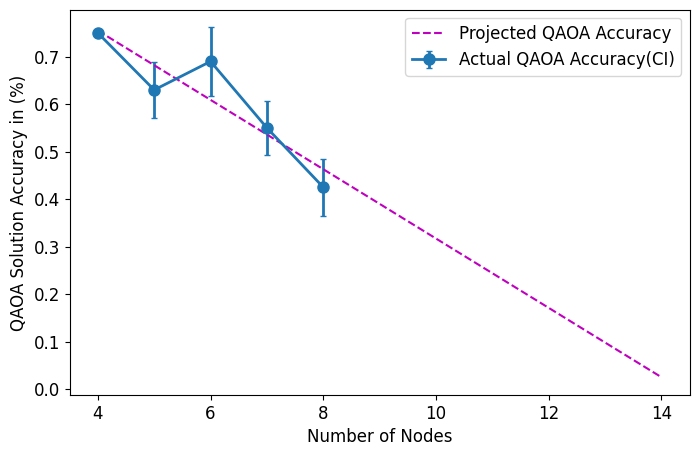

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Observed data 
rows = []
n_values = qaoa_accuracy.keys()
accuracy_time = qaoa_accuracy.values()


for algo, times_by_nodes in qaoa_accuracy.items():
    n=algo
    times = times_by_nodes
    avg = np.mean(times)
    ci = 1.96 * np.std(times, ddof=1)/np.sqrt(len(times)) if len(times) > 1 else 0
    rows.append({
        'Algorithm': algo,
        'Nodes': n,
        'AverageTime': avg,
        'CI_plus': ci,
        'CI_minus': ci,
        'MinTime': min(times),
        'MaxTime': max(times)
    })
print(rows)
algo_data = pd.DataFrame(rows)
plt.figure(figsize=(8, 5))

# Plot observed data points

plt.errorbar(algo_data['Nodes'], algo_data['AverageTime'], 
            yerr=[algo_data['CI_minus'], algo_data['CI_plus']], 
            linestyle='-', marker='o',
            markersize=8, linewidth=2, capsize=2, label=f'Actual QAOA Accuracy(CI)')
    
# Extended range for projection
full_n = np.arange(4, 15)
# Polynomial fit (degree 2)
poly_coeffs = np.polyfit(algo_data['Nodes'], algo_data['AverageTime'], 1)
poly_model = np.poly1d(poly_coeffs)
poly_proj = poly_model(full_n)

# # Plot projections as dashed lines
plt.plot(full_n, poly_proj, 'm--', label='Projected QAOA Accuracy')

plt.xlabel('Number of Nodes',fontsize=12)
plt.ylabel('QAOA Solution Accuracy in (%)',fontsize=12)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.grid(True, which='both', ls='--')
plt.show()


In [11]:
from collections import defaultdict
import json
def parse_qaoa_simulated1_log(file_path):
    """
    Parse QAOA log file and return:
      1. Average duration per entry (ms) for each node count
      2. Total estimated time (ms), scaled by p-level and iterations, for each node count
    Returns:
      total_time_by_nodes: defaultdict(list)
      avg_entry_time_by_nodes: defaultdict(list)
    """
    times_by_nodes = defaultdict(list)
    avg_times_by_nodes = defaultdict(list)
    accuracy_by_nodes = defaultdict(list)
    stats = defaultdict(list)
    with open(file_path, 'r') as f:
        data = json.load(f)

    data = data["experiment_data"]

    for key, entry in data.items():
        node_num = key.split("_")[0]  # Extract '2' from '2_1'
        current_exec_time = float(entry['real_execution_time'])
        current_iterations = int(entry['iterations'])
        accuracy =100 - float(entry['gap'])
        stats[node_num].append({
            'real_time' : current_exec_time,
            'iterations': current_iterations,
            "accuracy" : accuracy
        })
        # Process and compute values
    for node_count, runs in stats.items():
        try:
            avg_time = (sum(run['real_time'] for run in runs) / len(runs))*1000
            avg_times_by_nodes[node_count].append(avg_time)
            for run in runs:
                total_time = (run['real_time'] * 1024 * run['iterations'])
                # total_time = (sum(run['total_time_ns'] * 500 * run['iterations'] for run in runs))
                times_by_nodes[node_count].append(total_time)
                accuracy_by_nodes[node_count].append(run["accuracy"])
        except KeyError as e:
            print(f"Experiment {int(node_count)} missing key: {e}")
    return accuracy_by_nodes

In [12]:
accuracies = parse_qaoa_simulated1_log("./experiment_data_sorted.json")
print(accuracies)

defaultdict(<class 'list'>, {'2': [100.0, 100.0, 100.0, 100.0], '3': [100.0, 100.0, 100.0, 100.0, 100.0], '4': [99.99999999999999, 100.0, 74.6030836140515, 100.0, 100.0], '5': [100.0, 95.76289007670388, 100.0, 99.99999999999999, 75.47529276336047], '6': [100.0, 100.0, 78.7162107299645, 98.13421929101267, 97.55564627979084], '7': [86.99, 99.99999999999997, 99.99999999999997, 99.99999999999997, 86.99274961963715], '8': [97.08429650349318, 99.99999999999999, 97.78960583384391, 91.6404768809754, 96.20275095648368]})


In [13]:
import pandas as pd
import numpy as np
rows = []
for algo, times_by_nodes in accuracies.items():
        times = sorted(times_by_nodes)
        avg = np.mean(times)
        ci = 1.96 * np.std(times, ddof=1)/np.sqrt(len(times)) if len(times) > 1 else 0
        rows.append({
            'Algorithm': algo,
            'Nodes': algo,
            'AverageTime': avg,
            'CI_plus': ci,
            'CI_minus': ci,
            'MinTime': min(times),
            'MaxTime': max(times)
            })
            
df1 = pd.DataFrame(rows)

In [14]:
df1

,Algorithm,Nodes,AverageTime,CI_plus,CI_minus,MinTime,MaxTime
0,2,2,100.000000,0.000000,0.000000,100.000000,100.0
1,3,3,100.000000,0.000000,0.000000,100.000000,100.0
2,4,4,94.920617,9.955591,9.955591,74.603084,100.0
3,5,5,94.247637,9.337975,9.337975,75.475293,100.0
4,6,6,94.881215,7.978980,7.978980,78.716211,100.0
5,7,7,94.796550,6.245441,6.245441,86.990000,100.0
6,8,8,96.543426,2.699838,2.699838,91.640477,100.0


<Figure size 800x500 with 0 Axes>

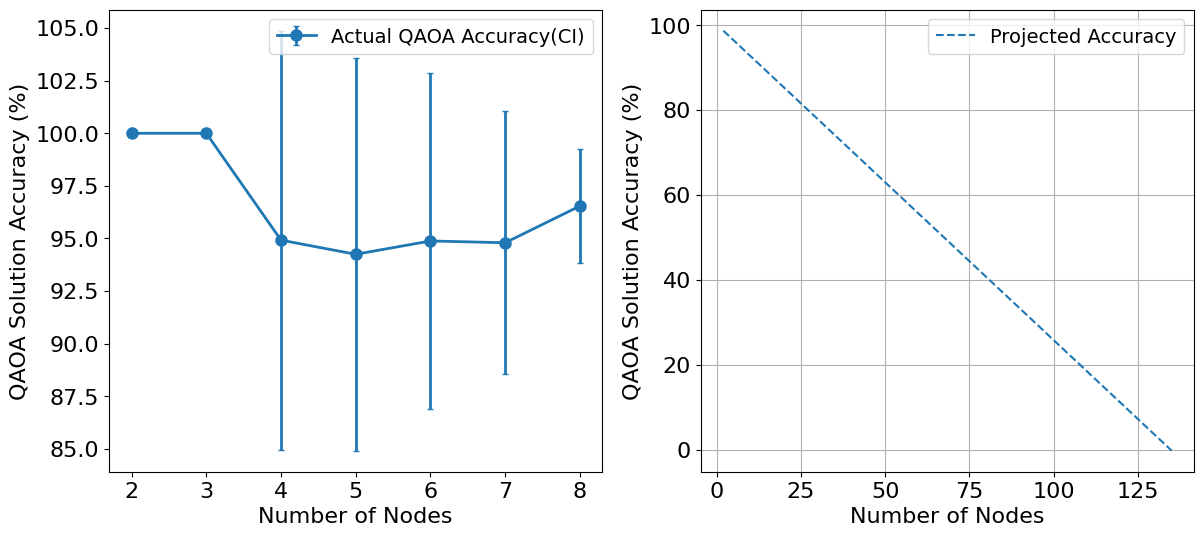

In [15]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def poly3_model(x, a, b, c, d, e):
    return e*x**4 + a* x**3 + b * x**2 + c * x + d 

def poly3_model1(x, a, c):
    return a * x + c 

# plt.errorbar(df1['Nodes'], df1['AverageTime'],
#             yerr=[df1['CI_minus'], df1['CI_plus']],
#             color='green', linestyle='-', # In ax1.errorbar call
#             marker='o', 
#             markersize=5, linewidth=2, capsize=4,
#             label=f'', alpha=0.8)
n_values = df1['Algorithm']
accuracy_time = df1['AverageTime']  # example time values (replace with your real timings)

n_values = np.array(n_values, dtype=float)
# Extended range for projection
full_n = np.arange(2,136)

popt, pcov = curve_fit(poly3_model1, n_values, accuracy_time)
fitted_curve = poly3_model1(full_n, *popt)
plt.figure(figsize=(8, 5))

# Plot observed data points  

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(14, 6))
ax1.errorbar(df1['Nodes'], df1['AverageTime'], 
            yerr=[df1['CI_minus'], df1['CI_plus']], 
            linestyle='-', marker='o',
            markersize=8, linewidth=2, capsize=2, label=f'Actual QAOA Accuracy(CI)')
ax2.plot(full_n, fitted_curve, '--', label='Projected Accuracy')
ax1.set_xlabel('Number of Nodes',fontsize=16)
ax1.set_ylabel('QAOA Solution Accuracy (%)',fontsize=16)
ax2.set_xlabel('Number of Nodes',fontsize=16)
ax2.set_ylabel('QAOA Solution Accuracy (%)',fontsize=16)
ax1.legend(fontsize=14)
ax2.legend(fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)
plt.grid(True)
plt.show()


LEFT PLOT DATA:
   Nodes  AverageTime   CI
0      4         75.5  7.5
1      5         64.0  6.5
2      6         70.0  7.0
3      7         55.0  5.5
4      8         43.0  4.5

RIGHT PLOT DATA:
   Nodes  AverageTime   CI_plus
0      2   100.000000  0.000000
1      3   100.000000  0.000000
2      4    94.920617  9.955591
3      5    94.247637  9.337975
4      6    94.881215  7.978980
5      7    94.796550  6.245441
6      8    96.543426  2.699838

LEFT PLOT - LINEAR MODEL:
  Equation: y = -7.4000·x + 105.90
  R² = 0.8310
  Reaches 0% at: 14.3 nodes

RIGHT PLOT - LINEAR MODEL:
  Equation: y = -0.7434·x + 100.20
  R² = 0.4117
  Reaches 0% at: 134.8 nodes

Right Plot - Accuracy Predictions:
  n =  10 nodes:  92.77%
  n =  20 nodes:  85.33%
  n =  30 nodes:  77.90%
  n =  50 nodes:  63.03%
  n = 100 nodes:  25.86%


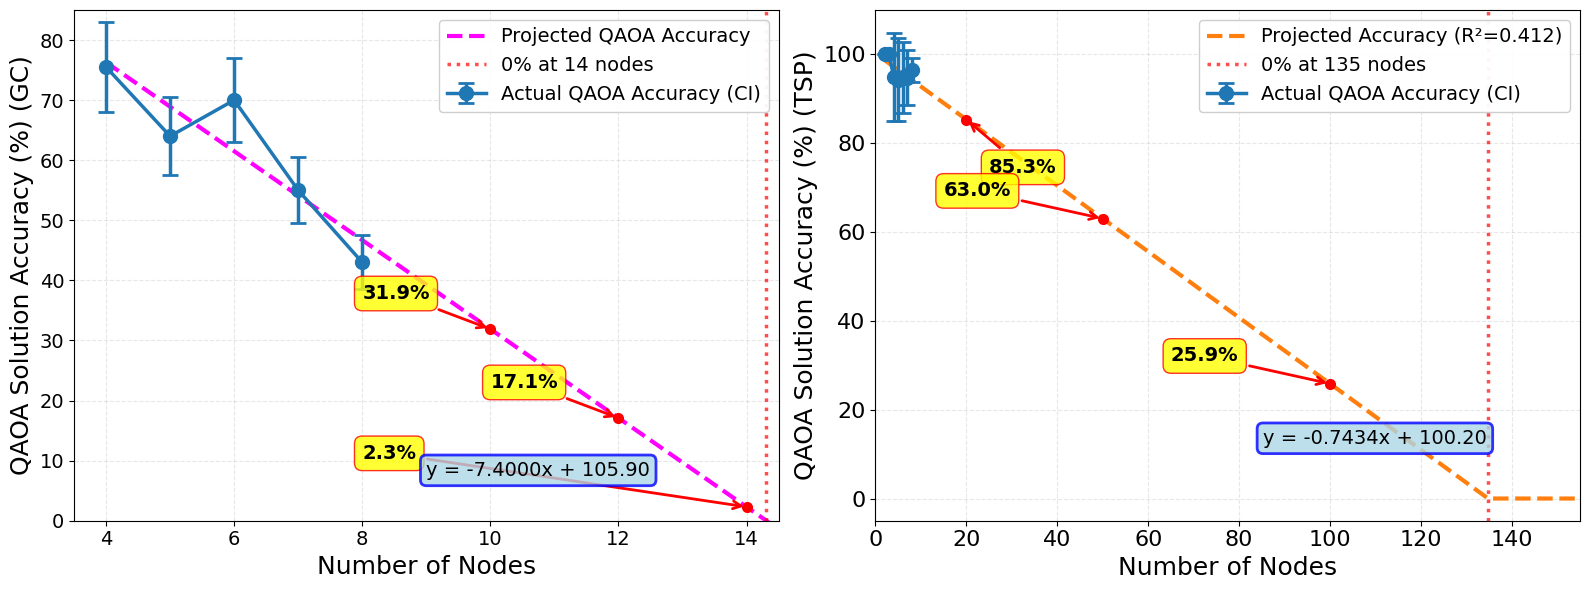


FINAL SUMMARY - BOTH PLOTS

LEFT PLOT:
  • Data: 5 points (nodes 4-8)
  • Linear fit: y = -7.4000x + 105.90
  • R² = 0.8310
  • Reaches 0% at 14.3 nodes

RIGHT PLOT:
  • Data: 7 points (nodes 2-8)
  • Linear fit: y = -0.7434x + 100.20
  • R² = 0.4117
  • Reaches 0% at 134.8 nodes
  • Plot extends to 155 nodes


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# Define linear decay model
def linear_decay(x, a, b):
    """Linear: a * x + b"""
    return a * x + b

# Your complete data for the right figure
data_right = {
    'Algorithm': [0, 1, 2, 3, 4, 5, 6],
    'Nodes': [2, 3, 4, 5, 6, 7, 8],
    'AverageTime': [100.000000, 100.000000, 94.920617, 94.247637, 94.881215, 94.796550, 96.543426],
    'CI_plus': [0.000000, 0.000000, 9.955591, 9.337975, 7.978980, 6.245441, 2.699838],
    'CI_minus': [0.000000, 0.000000, 9.955591, 9.337975, 7.978980, 6.245441, 2.699838],
    'MinTime': [100.000000, 100.000000, 74.603084, 75.475293, 78.716211, 86.990000, 91.640477],
    'MaxTime': [100.000000, 100.000000, 100.0, 100.0, 100.0, 100.0, 100.0]
}

df_right = pd.DataFrame(data_right)

# Your data for the left figure (replace with your actual data if different)
data_left = {
    'Nodes': [4, 5, 6, 7, 8],
    'AverageTime': [75.5, 64.0, 70.0, 55.0, 43.0],  # Replace with actual
    'CI': [7.5, 6.5, 7.0, 5.5, 4.5]  # Replace with actual
}
df_left = pd.DataFrame(data_left)

print("="*60)
print("LEFT PLOT DATA:")
print("="*60)
print(df_left[['Nodes', 'AverageTime', 'CI']])

print("\n" + "="*60)
print("RIGHT PLOT DATA:")
print("="*60)
print(df_right[['Nodes', 'AverageTime', 'CI_plus']])

# Create figure with matching style
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ===== LEFT PLOT: Linear fit to small range =====

# Linear fit for left plot
popt_left, pcov_left = curve_fit(linear_decay, df_left['Nodes'], df_left['AverageTime'])

# Calculate R² for left plot
residuals_left = df_left['AverageTime'] - linear_decay(df_left['Nodes'], *popt_left)
ss_res_left = np.sum(residuals_left**2)
ss_tot_left = np.sum((df_left['AverageTime'] - np.mean(df_left['AverageTime']))**2)
r2_left = 1 - (ss_res_left / ss_tot_left)

# Find where left plot reaches 0
if popt_left[0] < 0:
    x_zero_left = -popt_left[1] / popt_left[0]
    x_zero_left = max(10, min(x_zero_left, 500))
else:
    x_zero_left = 100  # Default if slope is non-negative

# Projection range for left plot (small range)
n_small = np.arange(df_left['Nodes'].min(), 15, 0.1)
fitted_left = linear_decay(n_small, *popt_left)

print(f"\n{'='*60}")
print("LEFT PLOT - LINEAR MODEL:")
print(f"{'='*60}")
print(f"  Equation: y = {popt_left[0]:.4f}·x + {popt_left[1]:.2f}")
print(f"  R² = {r2_left:.4f}")
print(f"  Reaches 0% at: {x_zero_left:.1f} nodes")

# Plot left panel
ax1.errorbar(df_left['Nodes'], df_left['AverageTime'], 
            yerr=df_left['CI'], 
            linestyle='-', marker='o', markersize=10, 
            linewidth=2.5, capsize=6, capthick=2,
            color='#1f77b4', ecolor='#1f77b4',
            label='Actual QAOA Accuracy (CI)', zorder=3)

ax1.plot(n_small, fitted_left, 
         linestyle='--', linewidth=3, 
         color='magenta',
         label=f'Projected QAOA Accuracy')

# Add vertical line at x=0 intercept for left plot (only if within range)
if x_zero_left <= 14.5:
    ax1.axvline(x=x_zero_left, color='red', linestyle=':', 
                linewidth=2.5, alpha=0.7, 
                label=f'0% at {x_zero_left:.0f} nodes')

# Annotate key points on left plot - KEEP WITHIN PLOT BOUNDS
key_nodes_left = [10, 12, 14]
for n_pt in key_nodes_left:
    if df_left['Nodes'].min() < n_pt < 14.5:
        acc_pt = linear_decay(n_pt, *popt_left)
        
        # Only annotate if within reasonable accuracy range
        if 1 < acc_pt < 80:
            ax1.plot(n_pt, acc_pt, 'o', color='red', markersize=7, zorder=4)
            
            # Smart positioning to keep annotations inside plot
            # Check if annotation would go outside bounds and adjust
            if acc_pt > 70:  # High up - annotate below
                xytext_offset = (-1, -12)
            elif acc_pt < 15:  # Low down - annotate above
                xytext_offset = (-6, 8)
            else:  # Middle - annotate to the side
                # Check if we're near the right edge
                if n_pt > 13:
                    xytext_offset = (-25, 5)  # Point left
                else:
                    xytext_offset = (-2, 5)  # Point right
            
            ax1.annotate(f'{acc_pt:.1f}%',
                        xy=(n_pt, acc_pt),
                        xytext=(n_pt + xytext_offset[0], acc_pt + xytext_offset[1]),
                        fontsize=14,
                        fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', 
                                 edgecolor='red', alpha=0.8),
                        arrowprops=dict(arrowstyle='->', color='red', lw=2))

ax1.set_xlabel('Number of Nodes', fontsize=18)
ax1.set_ylabel('QAOA Solution Accuracy (%) (GC)', fontsize=18)
ax1.legend(fontsize=14, loc='upper right', framealpha=0.95)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax1.set_ylim(0, 85)
ax1.set_xlim(df_left['Nodes'].min() - 0.5, 14.5)

# Add equation text box for left plot - positioned to stay inside
eq_text_left = f"y = {popt_left[0]:.4f}x + {popt_left[1]:.2f}"
ax1.text(0.50, 0.08, eq_text_left, transform=ax1.transAxes,
         fontsize=14, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='lightblue', 
                  edgecolor='blue', alpha=0.8, linewidth=2))

# ===== RIGHT PLOT: Linear fit extended to 0% =====

# Linear fit for right plot
popt_right, pcov_right = curve_fit(linear_decay, df_right['Nodes'], df_right['AverageTime'])

# Calculate R²
residuals_right = df_right['AverageTime'] - linear_decay(df_right['Nodes'], *popt_right)
ss_res_right = np.sum(residuals_right**2)
ss_tot_right = np.sum((df_right['AverageTime'] - np.mean(df_right['AverageTime']))**2)
r2_right = 1 - (ss_res_right / ss_tot_right)

# Find where right plot reaches 0
if popt_right[0] < 0:
    x_zero_right = -popt_right[1] / popt_right[0]
    x_zero_right = max(10, min(x_zero_right, 1000))
else:
    x_zero_right = 500
    print("⚠️ Warning: Right plot linear fit has non-negative slope!")

print(f"\n{'='*60}")
print("RIGHT PLOT - LINEAR MODEL:")
print(f"{'='*60}")
print(f"  Equation: y = {popt_right[0]:.4f}·x + {popt_right[1]:.2f}")
print(f"  R² = {r2_right:.4f}")
print(f"  Reaches 0% at: {x_zero_right:.1f} nodes")

# Create projection range extending to where accuracy hits 0
x_end = int(np.ceil(x_zero_right)) + 20
x_end = min(x_end, 800)
n_large = np.arange(2, x_end, 0.5)

# Generate fitted curve
fitted_right = linear_decay(n_large, *popt_right)
fitted_right = np.clip(fitted_right, 0, 100)

# Print predictions for right plot
print(f"\nRight Plot - Accuracy Predictions:")
print("="*40)
for n_pred in [10, 20, 30, 50, 100, 200]:
    if n_pred < x_end:
        acc_pred = linear_decay(n_pred, *popt_right)
        print(f"  n = {n_pred:3d} nodes: {max(0, acc_pred):6.2f}%")

# Plot right panel
ax2.errorbar(df_right['Nodes'], df_right['AverageTime'], 
            yerr=[df_right['CI_minus'], df_right['CI_plus']], 
            linestyle='-', marker='o', markersize=10, 
            linewidth=2.5, capsize=6, capthick=2,
            color='#1f77b4', ecolor='#1f77b4',
            label='Actual QAOA Accuracy (CI)', zorder=3)

ax2.plot(n_large, fitted_right, 
         linestyle='--', linewidth=3, 
         color='#ff7f0e',
         label=f'Projected Accuracy (R²={r2_right:.3f})')

# Add vertical line at x=0 intercept
ax2.axvline(x=x_zero_right, color='red', linestyle=':', 
            linewidth=2.5, alpha=0.7, 
            label=f'0% at {x_zero_right:.0f} nodes')

# Annotate key points on right plot
key_nodes_right = [20, 50, 100]
for n_pt in key_nodes_right:
    if 10 < n_pt < x_zero_right * 0.9:
        acc_pt = linear_decay(n_pt, *popt_right)
        
        if 1 < acc_pt < 99:
            ax2.plot(n_pt, acc_pt, 'o', color='red', markersize=7, zorder=4)
            
            # Smart positioning based on location and accuracy
            if acc_pt > 70:  # High accuracy - annotate below
                xytext_offset = (5, -12)
            elif acc_pt < 20:  # Low accuracy - annotate above
                xytext_offset = (5, 8)
            else:  # Middle range
                if n_pt < x_end * 0.3:
                    xytext_offset = (15, 5)
                else:
                    xytext_offset = (-35, 5)
            
            ax2.annotate(f'{acc_pt:.1f}%',
                        xy=(n_pt, acc_pt),
                        xytext=(n_pt + xytext_offset[0], acc_pt + xytext_offset[1]),
                        fontsize=14,
                        fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', 
                                 edgecolor='red', alpha=0.8),
                        arrowprops=dict(arrowstyle='->', color='red', lw=2))

ax2.set_xlabel('Number of Nodes', fontsize=18)
ax2.set_ylabel('QAOA Solution Accuracy (%) (TSP)', fontsize=18)
ax2.legend(fontsize=14, loc='upper right', framealpha=0.95)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax2.set_ylim(-5, 110)
ax2.set_xlim(0, x_end)

# Add equation text box for right plot
eq_text_right = f"y = {popt_right[0]:.4f}x + {popt_right[1]:.2f}"
ax2.text(0.55, 0.18, eq_text_right, transform=ax2.transAxes,
         fontsize=14, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', 
                  edgecolor='blue', alpha=0.8, linewidth=2))

plt.tight_layout()
plt.savefig('qaoa_accuracy_both_bounded.png', dpi=300, bbox_inches='tight')
plt.show()

# Final comprehensive summary
print(f"\n{'='*60}")
print("FINAL SUMMARY - BOTH PLOTS")
print(f"{'='*60}")
print(f"\nLEFT PLOT:")
print(f"  • Data: {len(df_left)} points (nodes {df_left['Nodes'].min()}-{df_left['Nodes'].max()})")
print(f"  • Linear fit: y = {popt_left[0]:.4f}x + {popt_left[1]:.2f}")
print(f"  • R² = {r2_left:.4f}")
print(f"  • Reaches 0% at {x_zero_left:.1f} nodes")
print(f"\nRIGHT PLOT:")
print(f"  • Data: {len(df_right)} points (nodes {df_right['Nodes'].min()}-{df_right['Nodes'].max()})")
print(f"  • Linear fit: y = {popt_right[0]:.4f}x + {popt_right[1]:.2f}")
print(f"  • R² = {r2_right:.4f}")
print(f"  • Reaches 0% at {x_zero_right:.1f} nodes")
print(f"  • Plot extends to {x_end} nodes")
print(f"{'='*60}")

Genetic Algorithm Data:
        instance   number of vertices  run  execution_time  best_distance  \
0    burma14.tsp                   14    1        0.015672           3838   
1    burma14.tsp                   14    2        0.015699           3986   
2    burma14.tsp                   14    3        0.015447           3836   
3  ulysses16.tsp                   16    1        0.017820           7801   
4  ulysses16.tsp                   16    2        0.018036           7992   

   optimal_distance_found   error [%]  best_fitness  convergence_generation  
0                    3367       13.99      3.532321                      27  
1                    3367       18.38      3.356831                      30  
2                    3367       13.93      3.534818                      85  
3                    6859       13.73      1.794044                      90  
4                    6859       16.52      1.760873                      69  

Columns: ['instance', ' number of vertices',

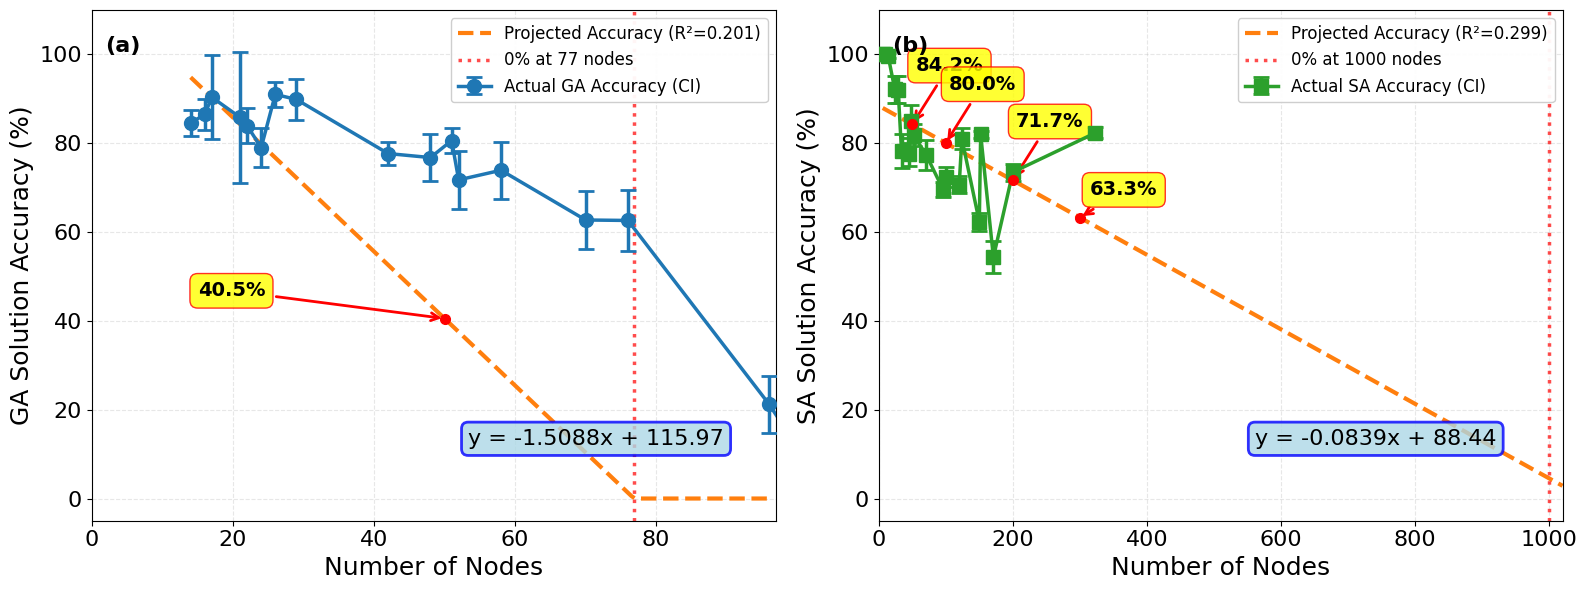


FINAL SUMMARY

GENETIC ALGORITHM:
  • Data points: 50 unique node sizes
  • Node range: 14-442
  • Accuracy range: -2593.85% - 98.83%
  • Linear fit: y = -1.5088x + 115.97
  • R² = 0.2014
  • Reaches 0% at 76.9 nodes
  • Plot extends to 97 nodes

SIMULATED ANNEALING:
  • Data points: 19 unique node sizes
  • Node range: 6-323
  • Accuracy range: 54.32% - 100.00%
  • Linear fit: y = -0.0839x + 88.44
  • R² = 0.2985
  • Reaches 0% at 1000.0 nodes
  • Plot extends to 1020 nodes

ACCURACY PREDICTIONS

Nodes      GA Accuracy     SA Accuracy    
----------------------------------------
50          40.53%          84.24%


In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# Define linear decay model
def linear_decay(x, a, b):
    """Linear: a * x + b"""
    return a * x + b

# Read the CSV files
# Replace these paths with your actual file paths
ga_df = pd.read_csv('genetic_algorithm_data.csv')
sa_df = pd.read_csv('simulated_annealing_data.csv')

print("="*60)
print("Genetic Algorithm Data:")
print("="*60)
print(ga_df.head())
print(f"\nColumns: {ga_df.columns.tolist()}")
print(f"Shape: {ga_df.shape}")

print("\n" + "="*60)
print("Simulated Annealing Data:")
print("="*60)
print(sa_df.head())
print(f"\nColumns: {sa_df.columns.tolist()}")
print(f"Shape: {sa_df.shape}")

# Clean column names (remove leading/trailing spaces)
ga_df.columns = ga_df.columns.str.strip()
sa_df.columns = sa_df.columns.str.strip()

# Identify the correct column names
# For GA data
vertices_col_ga = None
error_col_ga = None

for col in ga_df.columns:
    if 'vertices' in col.lower() or 'nodes' in col.lower():
        vertices_col_ga = col
    if 'error' in col.lower():
        error_col_ga = col

print(f"\n{'='*60}")
print(f"Detected GA columns:")
print(f"  Vertices column: {vertices_col_ga}")
print(f"  Error column: {error_col_ga}")

# For SA data
vertices_col_sa = None
error_col_sa = None

for col in sa_df.columns:
    if 'vertices' in col.lower() or 'nodes' in col.lower():
        vertices_col_sa = col
    if 'error' in col.lower():
        error_col_sa = col

print(f"\nDetected SA columns:")
print(f"  Vertices column: {vertices_col_sa}")
print(f"  Error column: {error_col_sa}")
print(f"{'='*60}")

# Check if columns were found
if vertices_col_ga is None or error_col_ga is None:
    print("\n❌ ERROR: Could not find required columns in GA data")
    print(f"Available columns: {ga_df.columns.tolist()}")
    raise ValueError("Required columns not found in GA data")
    
if vertices_col_sa is None or error_col_sa is None:
    print("\n❌ ERROR: Could not find required columns in SA data")
    print(f"Available columns: {sa_df.columns.tolist()}")
    raise ValueError("Required columns not found in SA data")

# Process Genetic Algorithm data
print("\n" + "="*60)
print("Processing GA data...")
print("="*60)

# Remove any rows with NaN values in critical columns
ga_df_clean = ga_df[[vertices_col_ga, error_col_ga]].dropna()
print(f"GA rows after cleaning: {len(ga_df_clean)}")

ga_grouped = ga_df_clean.groupby(vertices_col_ga).agg({
    error_col_ga: ['mean', 'std', 'count']
}).reset_index()

ga_grouped.columns = ['Nodes', 'Error_Mean', 'Error_Std', 'Count']
ga_grouped['Accuracy'] = 100 - ga_grouped['Error_Mean']
ga_grouped['CI'] = 1.96 * ga_grouped['Error_Std'] / np.sqrt(ga_grouped['Count'])
ga_grouped['CI'] = ga_grouped['CI'].fillna(0)

print("\nGenetic Algorithm - Processed Data:")
print(ga_grouped[['Nodes', 'Accuracy', 'CI']])

# Process Simulated Annealing data
print("\n" + "="*60)
print("Processing SA data...")
print("="*60)

# Remove any rows with NaN values in critical columns
sa_df_clean = sa_df[[vertices_col_sa, error_col_sa]].dropna()
print(f"SA rows after cleaning: {len(sa_df_clean)}")

# Check if we have any data
if len(sa_df_clean) == 0:
    print("⚠️ WARNING: No valid SA data after cleaning")
    print("Checking for data issues...")
    print(f"\nOriginal SA data sample:")
    print(sa_df[[vertices_col_sa, error_col_sa]].head(20))
    print(f"\nData types:")
    print(sa_df[[vertices_col_sa, error_col_sa]].dtypes)
    
    # Try to convert error column to numeric
    sa_df[error_col_sa] = pd.to_numeric(sa_df[error_col_sa], errors='coerce')
    sa_df_clean = sa_df[[vertices_col_sa, error_col_sa]].dropna()
    print(f"\nSA rows after numeric conversion: {len(sa_df_clean)}")

sa_grouped = sa_df_clean.groupby(vertices_col_sa).agg({
    error_col_sa: ['mean', 'std', 'count']
}).reset_index()

sa_grouped.columns = ['Nodes', 'Error_Mean', 'Error_Std', 'Count']
sa_grouped['Accuracy'] = 100 - sa_grouped['Error_Mean']
sa_grouped['CI'] = 1.96 * sa_grouped['Error_Std'] / np.sqrt(sa_grouped['Count'])
sa_grouped['CI'] = sa_grouped['CI'].fillna(0)

print("\nSimulated Annealing - Processed Data:")
print(sa_grouped[['Nodes', 'Accuracy', 'CI']])

# Check if we have enough data points for both
if len(ga_grouped) < 2:
    print("\n❌ ERROR: Not enough GA data points for fitting (need at least 2)")
    raise ValueError("Insufficient GA data")

if len(sa_grouped) < 2:
    print("\n❌ ERROR: Not enough SA data points for fitting (need at least 2)")
    raise ValueError("Insufficient SA data")

# ===== FIT BOTH MODELS FIRST =====

# Linear fit for GA
popt_ga, pcov_ga = curve_fit(linear_decay, ga_grouped['Nodes'], ga_grouped['Accuracy'])

# Calculate R² for GA
residuals_ga = ga_grouped['Accuracy'] - linear_decay(ga_grouped['Nodes'], *popt_ga)
ss_res_ga = np.sum(residuals_ga**2)
ss_tot_ga = np.sum((ga_grouped['Accuracy'] - np.mean(ga_grouped['Accuracy']))**2)
r2_ga = 1 - (ss_res_ga / ss_tot_ga) if ss_tot_ga > 0 else 0

# Find where GA reaches 0%
if popt_ga[0] < 0:
    x_zero_ga = -popt_ga[1] / popt_ga[0]
    x_zero_ga = max(10, min(x_zero_ga, 1000))
else:
    x_zero_ga = 500  # Default if slope is non-negative

# GA x-axis range (extends to its own zero point)
x_max_ga = int(np.ceil(x_zero_ga)) + 20
x_max_ga = min(x_max_ga, 1000)

# Linear fit for SA
popt_sa, pcov_sa = curve_fit(linear_decay, sa_grouped['Nodes'], sa_grouped['Accuracy'])

# Calculate R² for SA
residuals_sa = sa_grouped['Accuracy'] - linear_decay(sa_grouped['Nodes'], *popt_sa)
ss_res_sa = np.sum(residuals_sa**2)
ss_tot_sa = np.sum((sa_grouped['Accuracy'] - np.mean(sa_grouped['Accuracy']))**2)
r2_sa = 1 - (ss_res_sa / ss_tot_sa) if ss_tot_sa > 0 else 0

# Find where SA reaches 0%
if popt_sa[0] < 0:
    x_zero_sa = -popt_sa[1] / popt_sa[0]
    x_zero_sa = max(10, min(x_zero_sa, 1000))
else:
    x_zero_sa = 500  # Default if slope is non-negative

# SA x-axis range (extends to its own zero point)
x_max_sa = int(np.ceil(x_zero_sa)) + 20
x_max_sa = min(x_max_sa, 1100)

print(f"\n{'='*60}")
print("GENETIC ALGORITHM - LINEAR MODEL:")
print(f"{'='*60}")
print(f"  Equation: y = {popt_ga[0]:.4f}·x + {popt_ga[1]:.2f}")
print(f"  R² = {r2_ga:.4f}")
print(f"  Reaches 0% at: {x_zero_ga:.1f} nodes")
print(f"  Plot x-axis: 0 to {x_max_ga} nodes")

print(f"\n{'='*60}")
print("SIMULATED ANNEALING - LINEAR MODEL:")
print(f"{'='*60}")
print(f"  Equation: y = {popt_sa[0]:.4f}·x + {popt_sa[1]:.2f}")
print(f"  R² = {r2_sa:.4f}")
print(f"  Reaches 0% at: {x_zero_sa:.1f} nodes")
print(f"  Plot x-axis: 0 to {x_max_sa} nodes")

# Create projection ranges for both algorithms (INDEPENDENT ranges)
n_ga = np.arange(ga_grouped['Nodes'].min(), x_max_ga, 0.5)
fitted_ga = linear_decay(n_ga, *popt_ga)
fitted_ga = np.clip(fitted_ga, 0, 100)

n_sa = np.arange(sa_grouped['Nodes'].min(), x_max_sa, 0.5)
fitted_sa = linear_decay(n_sa, *popt_sa)
fitted_sa = np.clip(fitted_sa, 0, 200)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.15)

# ===== LEFT PLOT: Genetic Algorithm Accuracy =====

# Plot GA
ax1.errorbar(ga_grouped['Nodes'], ga_grouped['Accuracy'], 
            yerr=ga_grouped['CI'], 
            linestyle='-', marker='o', markersize=10, 
            linewidth=2.5, capsize=6, capthick=2,
            color='#1f77b4', ecolor='#1f77b4',
            label='Actual GA Accuracy (CI)', zorder=3)

ax1.plot(n_ga, fitted_ga, 
         linestyle='--', linewidth=3, 
         color='#ff7f0e',
         label=f'Projected Accuracy (R²={r2_ga:.3f})')

ax1.axvline(x=x_zero_ga, color='red', linestyle=':', 
            linewidth=2.5, alpha=0.7, 
            label=f'0% at {x_zero_ga:.0f} nodes')

# Annotate key points for GA
key_nodes_ga = [50, 100, 200, 300, 400, 500, 600, 700, 800]
annotations_added = 0
for n_pt in key_nodes_ga:
    if ga_grouped['Nodes'].min() < n_pt < x_zero_ga * 0.95 and n_pt < x_max_ga and annotations_added < 4:
        acc_pt = linear_decay(n_pt, *popt_ga)
        
        if 1 < acc_pt < 99:
            ax1.plot(n_pt, acc_pt, 'o', color='red', markersize=7, zorder=4)
            
            if acc_pt > 70:
                xytext_offset = (5, -12)
            elif acc_pt < 20:
                xytext_offset = (5, 8)
            else:
                if n_pt < x_max_ga * 0.3:
                    xytext_offset = (15, 5)
                else:
                    xytext_offset = (-35, 5)
            
            ax1.annotate(f'{acc_pt:.1f}%',
                        xy=(n_pt, acc_pt),
                        xytext=(n_pt + xytext_offset[0], acc_pt + xytext_offset[1]),
                        fontsize=14,
                        fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', 
                                 edgecolor='red', alpha=0.8),
                        arrowprops=dict(arrowstyle='->', color='red', lw=2))
            annotations_added += 1

ax1.set_xlabel('Number of Nodes', fontsize=18)
ax1.set_ylabel('GA Solution Accuracy (%)', fontsize=18)
ax1.legend(fontsize=12, loc='upper right', framealpha=0.95)
ax1.tick_params(axis='both', which='major', labelsize=16)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax1.set_ylim(-5, 110)
ax1.set_xlim(0, x_max_ga)  # Independent x-axis for GA
ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes, fontsize=16, 
         fontweight='bold', verticalalignment='top')

eq_text_ga = f"y = {popt_ga[0]:.4f}x + {popt_ga[1]:.2f}"
ax1.text(0.55, 0.18, eq_text_ga, transform=ax1.transAxes,
         fontsize=16, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', 
                  edgecolor='blue', alpha=0.8, linewidth=2))

# ===== RIGHT PLOT: Simulated Annealing Accuracy =====

# Plot SA
ax2.errorbar(sa_grouped['Nodes'], sa_grouped['Accuracy'], 
            yerr=sa_grouped['CI'], 
            linestyle='-', marker='s', markersize=10, 
            linewidth=2.5, capsize=6, capthick=2,
            color='#2ca02c', ecolor='#2ca02c',
            label='Actual SA Accuracy (CI)', zorder=3)

ax2.plot(n_sa, fitted_sa, 
         linestyle='--', linewidth=3, 
         color='#ff7f0e',
         label=f'Projected Accuracy (R²={r2_sa:.3f})')

ax2.axvline(x=x_zero_sa, color='red', linestyle=':', 
            linewidth=2.5, alpha=0.7, 
            label=f'0% at {x_zero_sa:.0f} nodes')

# Annotate key points for SA
key_nodes_sa = [50, 100, 200, 300, 400, 500, 600, 700, 800, 1000]
annotations_added = 0
for n_pt in key_nodes_sa:
    if sa_grouped['Nodes'].min() < n_pt < x_zero_sa * 0.95 and n_pt < x_max_sa and annotations_added < 4:
        acc_pt = linear_decay(n_pt, *popt_sa)
        
        if 1 < acc_pt < 99:
            ax2.plot(n_pt, acc_pt, 'o', color='red', markersize=7, zorder=4)
            
            if acc_pt > 70:
                xytext_offset = (5, 12)
            elif acc_pt < 20:
                xytext_offset = (5, 8)
            else:
                if n_pt < x_max_sa * 0.3:
                    xytext_offset = (15, 5)
                else:
                    xytext_offset = (-35, 5)
            
            ax2.annotate(f'{acc_pt:.1f}%',
                        xy=(n_pt, acc_pt),
                        xytext=(n_pt + xytext_offset[0], acc_pt + xytext_offset[1]),
                        fontsize=14,
                        fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', 
                                 edgecolor='red', alpha=0.8),
                        arrowprops=dict(arrowstyle='->', color='red', lw=2))
            annotations_added += 1

ax2.set_xlabel('Number of Nodes', fontsize=18)
ax2.set_ylabel('SA Solution Accuracy (%)', fontsize=18)
ax2.legend(fontsize=12, loc='upper right', framealpha=0.95)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax2.set_ylim(-5, 110)
ax2.set_xlim(0, x_max_sa)  # Independent x-axis for SA
ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes, fontsize=16, 
         fontweight='bold', verticalalignment='top')

eq_text_sa = f"y = {popt_sa[0]:.4f}x + {popt_sa[1]:.2f}"
ax2.text(0.55, 0.18, eq_text_sa, transform=ax2.transAxes,
         fontsize=16, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', 
                  edgecolor='blue', alpha=0.8, linewidth=2))

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)

plt.savefig('ga_sa_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Final summary
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"\nGENETIC ALGORITHM:")
print(f"  • Data points: {len(ga_grouped)} unique node sizes")
print(f"  • Node range: {ga_grouped['Nodes'].min()}-{ga_grouped['Nodes'].max()}")
print(f"  • Accuracy range: {ga_grouped['Accuracy'].min():.2f}% - {ga_grouped['Accuracy'].max():.2f}%")
print(f"  • Linear fit: y = {popt_ga[0]:.4f}x + {popt_ga[1]:.2f}")
print(f"  • R² = {r2_ga:.4f}")
print(f"  • Reaches 0% at {x_zero_ga:.1f} nodes")
print(f"  • Plot extends to {x_max_ga} nodes")

print(f"\nSIMULATED ANNEALING:")
print(f"  • Data points: {len(sa_grouped)} unique node sizes")
print(f"  • Node range: {sa_grouped['Nodes'].min()}-{sa_grouped['Nodes'].max()}")
print(f"  • Accuracy range: {sa_grouped['Accuracy'].min():.2f}% - {sa_grouped['Accuracy'].max():.2f}%")
print(f"  • Linear fit: y = {popt_sa[0]:.4f}x + {popt_sa[1]:.2f}")
print(f"  • R² = {r2_sa:.4f}")
print(f"  • Reaches 0% at {x_zero_sa:.1f} nodes")
print(f"  • Plot extends to {x_max_sa} nodes")
print(f"{'='*60}")

# Print predictions
print(f"\n{'='*60}")
print("ACCURACY PREDICTIONS")
print(f"{'='*60}")
print(f"\n{'Nodes':<10} {'GA Accuracy':<15} {'SA Accuracy':<15}")
print("-" * 40)
max_pred = min(x_max_ga, x_max_sa)
for n_pred in [50, 100, 200, 300, 400, 500, 600, 700, 800]:
    if n_pred < max_pred:
        ga_acc = linear_decay(n_pred, *popt_ga)
        sa_acc = linear_decay(n_pred, *popt_sa)
        print(f"{n_pred:<10} {max(0, ga_acc):>6.2f}%{'':<8} {max(0, sa_acc):>6.2f}%")

In [22]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================
# 1. FILENAMES (edit paths if needed)
# =========================================
SAT_LOG_PATH    = "stat_log_file"          # exact SAT-based chromatic numbers (ZykovColor log)
DSATUR_LOG_PATH = "tmp_stat_info_small"    # DSATUR runs log
MCS_LOG_PATH    = "stat_info_mcs_small"    # MCS runs log


# =========================================
# 2. PARSE SAT / EXACT LOG (ZykovColor)
# =========================================
def parse_sat_log(path):
    """
    Parse ZykovColor / SAT solver log to extract:
      - instance filename (e.g. ER5.5_inst1.col)
      - Nodes (n)
      - InstIdx (instance index, like 1..k)
      - Chromatic_Exact (true chromatic number)
    Assumes naming like ER5.5_inst1.col:
      <prefix><n>.<p>_inst<idx>.col
    """
    with open(path, "r") as f:
        text = f.read()

    rows = []
    current_instance = None
    current_n = None
    current_inst_idx = None

    for line in text.splitlines():
        line = line.strip()

        # Example:
        # c Options : Instance                = ER5.5_inst1.col
        m_inst = re.search(r"Instance\s*=\s*([A-Za-z0-9_.\/-]+\.col)", line)
        if m_inst:
            current_instance = m_inst.group(1)

            # Try to extract n and inst index from name like ER5.5_inst1.col
            m_name = re.search(r"([A-Za-z]+)(\d+)\.(\d+)_inst(\d+)\.col", current_instance)
            if m_name:
                # prefix = m_name.group(1)   # e.g. 'ER' (not needed)
                current_n       = int(m_name.group(2))    # number of vertices
                # p_param      = int(m_name.group(3))    # probability*10 (optional)
                current_inst_idx = int(m_name.group(4))   # instance index 1..k
            else:
                current_n = None
                current_inst_idx = None
            continue

        # Lines containing chromatic number:
        #   "Result: Chromatic number of 4 was determined in pre-processing."
        #   "IncSatGC computed chromatic number of 4"
        m_chi1 = re.search(r"chromatic number of\s+(\d+)", line, re.IGNORECASE)
        m_chi2 = re.search(r"computed chromatic number of\s+(\d+)", line, re.IGNORECASE)
        m_chi  = m_chi1 or m_chi2

        if m_chi and current_instance is not None:
            chi_exact = int(m_chi.group(1))
            rows.append({
                "Instance": current_instance,
                "Nodes": current_n,
                "InstIdx": current_inst_idx,
                "Chromatic_Exact": chi_exact
            })

    df = pd.DataFrame(rows)
    print("\n[parse_sat_log] Parsed SAT exact results:")
    print(df.head())
    print(f"Total SAT instances parsed: {len(df)}")
    return df


# =========================================
# 3. PARSE DSATUR LOG
# =========================================
def parse_dsatur_log(path):
    """
    Parse DSATUR log of the form:

      NUMBER OF NODES 3
      ...
      Iteration 2
      8848ns
      DSATUR Chromatic Number: 2
      ...

    Returns DataFrame with:
      Nodes, InstIdx, Chromatic_DS
    """
    with open(path, "r") as f:
        text = f.read()

    rows = []
    current_n = None
    current_iter = None

    for line in text.splitlines():
        line = line.strip()

        # "NUMBER OF NODES 5"
        m_nodes = re.match(r"NUMBER OF NODES (\d+)", line)
        if m_nodes:
            current_n = int(m_nodes.group(1))
            current_iter = None
            continue

        # "Iteration 3"
        m_it = re.match(r"Iteration (\d+)", line)
        if m_it:
            current_iter = int(m_it.group(1))
            continue

        # "DSATUR Chromatic Number: 2"
        m_chi = re.match(r"DSATUR Chromatic Number:\s*(\d+)", line)
        if m_chi and current_n is not None and current_iter is not None:
            chi_ds = int(m_chi.group(1))
            rows.append({
                "Nodes": current_n,
                "InstIdx": current_iter,
                "Chromatic_DS": chi_ds
            })

    df = pd.DataFrame(rows)
    print("\n[parse_dsatur_log] Parsed DSATUR results:")
    print(df.head())
    print(f"Total DSATUR instances parsed: {len(df)}")
    return df


# =========================================
# 4. PARSE MCS LOG
# =========================================
def parse_mcs_log(path):
    """
    Parse MCS log of the form:

      ALGORITHM MCS

      NUMBER OF NODES 1
      ...
      Iteration 1
      5968ns
      MCS Chromatic Number: 1
      ...

    Returns DataFrame with:
      Nodes, InstIdx, Chromatic_MCS
    """
    with open(path, "r") as f:
        text = f.read()

    rows = []
    current_n = None
    current_iter = None

    for line in text.splitlines():
        line = line.strip()

        # "NUMBER OF NODES 5"
        m_nodes = re.match(r"NUMBER OF NODES (\d+)", line)
        if m_nodes:
            current_n = int(m_nodes.group(1))
            current_iter = None
            continue

        # "Iteration 3"
        m_it = re.match(r"Iteration (\d+)", line)
        if m_it:
            current_iter = int(m_it.group(1))
            continue

        # "MCS Chromatic Number: 2"
        m_chi = re.match(r"MCS Chromatic Number:\s*(\d+)", line)
        if m_chi and current_n is not None and current_iter is not None:
            chi_mcs = int(m_chi.group(1))
            rows.append({
                "Nodes": current_n,
                "InstIdx": current_iter,
                "Chromatic_MCS": chi_mcs
            })

    df = pd.DataFrame(rows)
    print("\n[parse_mcs_log] Parsed MCS results:")
    print(df.head())
    print(f"Total MCS instances parsed: {len(df)}")
    return df


# =========================================
# 5. MAIN: parse, merge, compute accuracies
# =========================================
sat_df    = parse_sat_log(SAT_LOG_PATH)
dsatur_df = parse_dsatur_log(DSATUR_LOG_PATH)
mcs_df    = parse_mcs_log(MCS_LOG_PATH)

# ---- DSATUR vs exact ----
dsatur_merged = dsatur_df.merge(
    sat_df[["Nodes", "InstIdx", "Chromatic_Exact"]],
    on=["Nodes", "InstIdx"],
    how="inner"
)

print("\n[DSATUR merged with SAT]:")
print(dsatur_merged.head())
print(f"Merged DSATUR rows: {len(dsatur_merged)}")

# Sanity check: DSATUR shouldn't beat exact
bad_ds = dsatur_merged[dsatur_merged["Chromatic_DS"] < dsatur_merged["Chromatic_Exact"]]
if not bad_ds.empty:
    print("\n⚠️ WARNING: DSATUR uses fewer colors than exact for some rows:")
    print(bad_ds.head())

dsatur_merged["Accuracy_DS"] = 100.0 * dsatur_merged["Chromatic_Exact"] / dsatur_merged["Chromatic_DS"]

# Cap at 100%
dsatur_merged["Accuracy_DS"] = dsatur_merged["Accuracy_DS"].clip(upper=100)


# ---- MCS vs exact ----
mcs_merged = mcs_df.merge(
    sat_df[["Nodes", "InstIdx", "Chromatic_Exact"]],
    on=["Nodes", "InstIdx"],
    how="inner"
)

print("\n[MCS merged with SAT]:")
print(mcs_merged.head())
print(f"Merged MCS rows: {len(mcs_merged)}")

bad_mcs = mcs_merged[mcs_merged["Chromatic_MCS"] < mcs_merged["Chromatic_Exact"]]
if not bad_mcs.empty:
    print("\n⚠️ WARNING: MCS uses fewer colors than exact for some rows:")
    print(bad_mcs.head())

mcs_merged["Accuracy_MCS"] = 100.0 * mcs_merged["Chromatic_Exact"] / mcs_merged["Chromatic_MCS"]

# Cap at 100%
mcs_merged["Accuracy_MCS"] = mcs_merged["Accuracy_MCS"].clip(upper=100)

# =========================================
# 6. Aggregate by Nodes (mean accuracy + CI)
# =========================================
def aggregate_accuracy(df, acc_col, name="ALG"):
    grouped = df.groupby("Nodes").agg({
        acc_col: ["mean", "std", "count"]
    }).reset_index()
    grouped.columns = ["Nodes", "Accuracy", "Accuracy_Std", "Count"]
    grouped["CI"] = 1.96 * grouped["Accuracy_Std"] / np.sqrt(grouped["Count"])
    grouped["CI"] = grouped["CI"].fillna(0.0)
    print(f"\n[{name} accuracy aggregated by Nodes]:")
    print(grouped)
    return grouped

dsatur_grouped = aggregate_accuracy(dsatur_merged, "Accuracy_DS", name="DSATUR")
mcs_grouped    = aggregate_accuracy(mcs_merged, "Accuracy_MCS", name="MCS")



[parse_sat_log] Parsed SAT exact results:
          Instance  Nodes  InstIdx  Chromatic_Exact
0  ER5.5_inst1.col      5        1                4
1  ER5.5_inst1.col      5        1                4
2  ER5.5_inst2.col      5        2                3
3  ER5.5_inst2.col      5        2                3
4  ER5.5_inst3.col      5        3                3
Total SAT instances parsed: 192

[parse_dsatur_log] Parsed DSATUR results:
   Nodes  InstIdx  Chromatic_DS
0      1        1             1
1      1        2             1
2      1        3             1
3      1        4             1
4      1        5             1
Total DSATUR instances parsed: 1000

[parse_mcs_log] Parsed MCS results:
   Nodes  InstIdx  Chromatic_MCS
0      1        1              1
1      1        2              1
2      1        3              1
3      1        4              1
4      1        5              1
Total MCS instances parsed: 1000

[DSATUR merged with SAT]:
   Nodes  InstIdx  Chromatic_DS  Chromatic_Exac

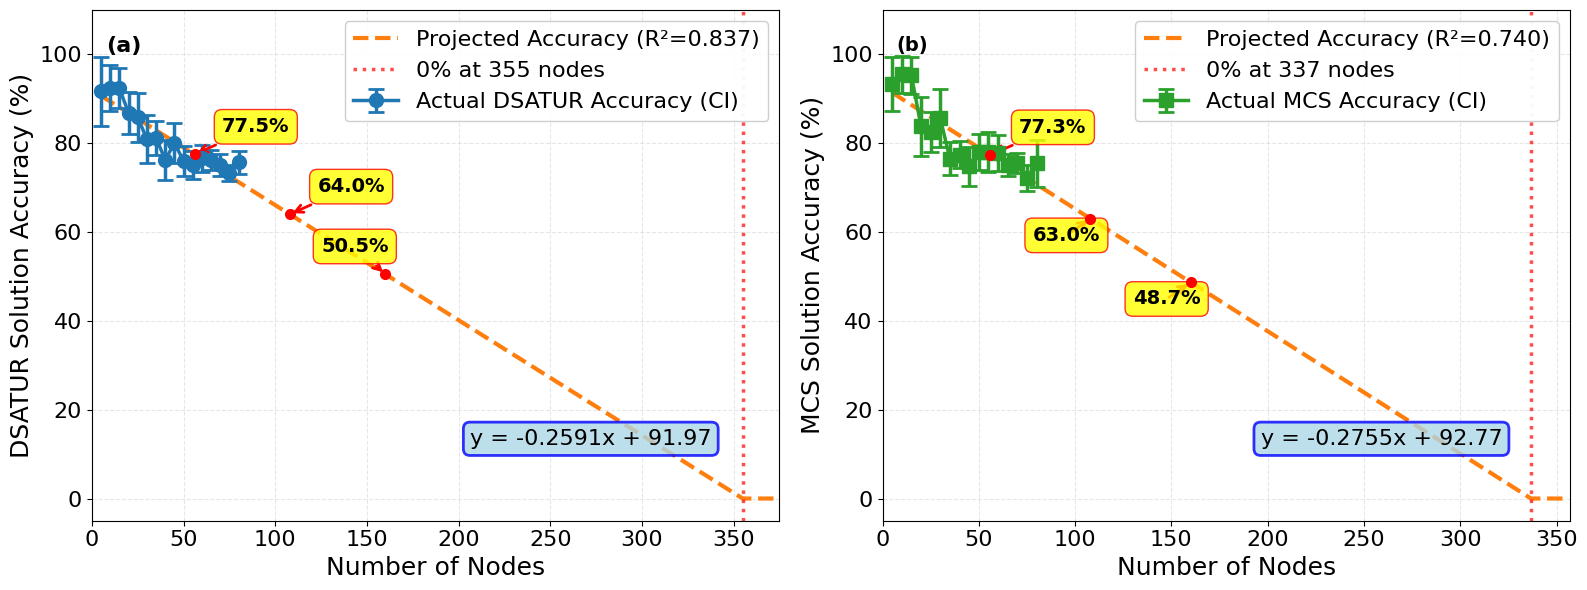

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -------------------------------------------------
# Helper: simple linear model
# -------------------------------------------------
def linear_decay(x, a, b):
    return a * x + b

# -------------------------------------------------
# 1) Fit DSATUR linear model
# -------------------------------------------------
x_ds = dsatur_grouped["Nodes"].values
y_ds = dsatur_grouped["Accuracy"].values

# Linear fit
popt_ds, _ = curve_fit(linear_decay, x_ds, y_ds)
a_ds, b_ds = popt_ds

# R²
residuals_ds = y_ds - linear_decay(x_ds, *popt_ds)
ss_res_ds = np.sum(residuals_ds ** 2)
ss_tot_ds = np.sum((y_ds - np.mean(y_ds)) ** 2)
r2_ds = 1 - ss_res_ds / ss_tot_ds if ss_tot_ds > 0 else 0.0

# Where DSATUR accuracy hits 0%
if a_ds < 0:
    x_zero_ds = -b_ds / a_ds
    x_zero_ds = max(x_ds.min(), min(x_zero_ds, 1000))  # clamp
else:
    x_zero_ds = 500.0  # fallback if slope >= 0

x_max_ds = int(np.ceil(x_zero_ds)) + 20
x_max_ds = min(x_max_ds, 1000)
x_max_ds = max(x_max_ds, int(x_ds.max()) + 5)

# Projection curve for DSATUR
n_ds = np.arange(x_ds.min(), x_max_ds, 0.5)
fitted_ds = linear_decay(n_ds, *popt_ds)
fitted_ds = np.clip(fitted_ds, 0, 100)  # keep in [0,100]

# -------------------------------------------------
# 2) Fit MCS linear model
# -------------------------------------------------
x_mcs = mcs_grouped["Nodes"].values
y_mcs = mcs_grouped["Accuracy"].values

popt_mcs, _ = curve_fit(linear_decay, x_mcs, y_mcs)
a_mcs, b_mcs = popt_mcs

residuals_mcs = y_mcs - linear_decay(x_mcs, *popt_mcs)
ss_res_mcs = np.sum(residuals_mcs ** 2)
ss_tot_mcs = np.sum((y_mcs - np.mean(y_mcs)) ** 2)
r2_mcs = 1 - ss_res_mcs / ss_tot_mcs if ss_tot_mcs > 0 else 0.0

if a_mcs < 0:
    x_zero_mcs = -b_mcs / a_mcs
    x_zero_mcs = max(x_mcs.min(), min(x_zero_mcs, 1000))
else:
    x_zero_mcs = 500.0

x_max_mcs = int(np.ceil(x_zero_mcs)) + 20
x_max_mcs = min(x_max_mcs, 1000)
x_max_mcs = max(x_max_mcs, int(x_mcs.max()) + 5)

n_mcs = np.arange(x_mcs.min(), x_max_mcs, 0.5)
fitted_mcs = linear_decay(n_mcs, *popt_mcs)
fitted_mcs = np.clip(fitted_mcs, 0, 100)

# -------------------------------------------------
# 3) Create GA/SA-style figure: DSATUR & MCS
# -------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.15)

# ===== LEFT subplot: DSATUR =====
ax1.errorbar(
    dsatur_grouped["Nodes"], dsatur_grouped["Accuracy"],
    yerr=dsatur_grouped["CI"],
    linestyle='-', marker='o', markersize=10,
    linewidth=2.5, capsize=6, capthick=2,
    color='#1f77b4', ecolor='#1f77b4',
    label='Actual DSATUR Accuracy (CI)', zorder=3
)

ax1.plot(
    n_ds, fitted_ds,
    linestyle='--', linewidth=3,
    color='#ff7f0e',
    label=f'Projected Accuracy (R²={r2_ds:.3f})'
)

ax1.axvline(
    x=x_zero_ds, color='red', linestyle=':',
    linewidth=2.5, alpha=0.7,
    label=f'0% at {x_zero_ds:.0f} nodes'
)

# Annotate a few projected points (similar yellow boxes)
key_nodes_ds = np.linspace(x_ds.min(), min(x_zero_ds, x_ds.max()*2), 4, dtype=int)
annotations_added = 0
for n_pt in key_nodes_ds:
    if x_ds.min() < n_pt < x_zero_ds * 0.95 and n_pt < x_max_ds and annotations_added < 4:
        acc_pt = linear_decay(n_pt, *popt_ds)
        if 1 < acc_pt < 99:
            ax1.plot(n_pt, acc_pt, 'o', color='red', markersize=7, zorder=4)
            if acc_pt > 80:
                xy_off = (5, -12)
            elif acc_pt < 20:
                xy_off = (5, 8)
            else:
                xy_off = (15, 5) if n_pt < x_max_ds * 0.3 else (-35, 5)
            ax1.annotate(
                f'{acc_pt:.1f}%',
                xy=(n_pt, acc_pt),
                xytext=(n_pt + xy_off[0], acc_pt + xy_off[1]),
                fontsize=14, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow',
                          edgecolor='red', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red', lw=2)
            )
            annotations_added += 1

ax1.set_xlabel('Number of Nodes', fontsize=18)
ax1.set_ylabel('DSATUR Solution Accuracy (%)', fontsize=18)
ax1.set_ylim(-5, 110)
ax1.set_xlim(0, x_max_ds)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax1.tick_params(axis='both', which='major', labelsize=16)
ax1.legend(fontsize=16, loc='upper right', framealpha=0.95)
ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes,
         fontsize=16, fontweight='bold', va='top')

eq_text_ds = f"y = {a_ds:.4f}x + {b_ds:.2f}"
ax1.text(
    0.55, 0.18, eq_text_ds, transform=ax1.transAxes,
    fontsize=16, va='top',
    bbox=dict(boxstyle='round', facecolor='lightblue',
              edgecolor='blue', alpha=0.8, linewidth=2)
)

# ===== RIGHT subplot: MCS =====
ax2.errorbar(
    mcs_grouped["Nodes"], mcs_grouped["Accuracy"],
    yerr=mcs_grouped["CI"],
    linestyle='-', marker='s', markersize=10,
    linewidth=2.5, capsize=6, capthick=2,
    color='#2ca02c', ecolor='#2ca02c',
    label='Actual MCS Accuracy (CI)', zorder=3
)

ax2.plot(
    n_mcs, fitted_mcs,
    linestyle='--', linewidth=3,
    color='#ff7f0e',
    label=f'Projected Accuracy (R²={r2_mcs:.3f})'
)

ax2.axvline(
    x=x_zero_mcs, color='red', linestyle=':',
    linewidth=2.5, alpha=0.7,
    label=f'0% at {x_zero_mcs:.0f} nodes'
)

key_nodes_mcs = np.linspace(x_mcs.min(), min(x_zero_mcs, x_mcs.max()*2), 4, dtype=int)
annotations_added = 0
for n_pt in key_nodes_mcs:
    if x_mcs.min() < n_pt < x_zero_mcs * 0.95 and n_pt < x_max_mcs and annotations_added < 4:
        acc_pt = linear_decay(n_pt, *popt_mcs)
        if 1 < acc_pt < 99:
            ax2.plot(n_pt, acc_pt, 'o', color='red', markersize=7, zorder=4)
            if acc_pt > 80:
                xy_off = (5, -14)
            elif acc_pt < 20:
                xy_off = (5, 8)
            else:
                xy_off = (15, 5) if n_pt < x_max_mcs * 0.3 else (-30, -5)
            ax2.annotate(
                f'{acc_pt:.1f}%',
                xy=(n_pt, acc_pt),
                xytext=(n_pt + xy_off[0], acc_pt + xy_off[1]),
                fontsize=14, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow',
                          edgecolor='red', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red', lw=2)
            )
            annotations_added += 1

ax2.set_xlabel('Number of Nodes', fontsize=18)
ax2.set_ylabel('MCS Solution Accuracy (%)', fontsize=18)
ax2.set_ylim(-5, 110)
ax2.set_xlim(0, x_max_mcs)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.legend(fontsize=16, loc='upper right', framealpha=0.95)
ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes,
         fontsize=14, fontweight='bold', va='top')

eq_text_mcs = f"y = {a_mcs:.4f}x + {b_mcs:.2f}"
ax2.text(
    0.55, 0.18, eq_text_mcs, transform=ax2.transAxes,
    fontsize=16, va='top',
    bbox=dict(boxstyle='round', facecolor='lightblue',
              edgecolor='blue', alpha=0.8, linewidth=2)
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)

plt.savefig('dsatur_mcs_accuracy_projection.png', dpi=300, bbox_inches='tight')
plt.show()


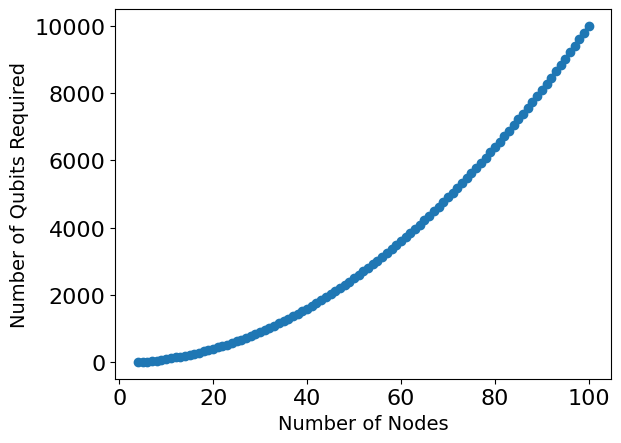

In [66]:
# Plot 2 (Top Right): Qubit Requirements
x_known = np.array([2, 3, 4, 5, 6, 7, 8])
y_known_theo = np.array([4, 9, 16, 25, 35, 47, 64])
y_known_act = np.array([])

# Interpolation range
x_interp = np.arange(4, 9)
y_interp = np.interp(x_interp, x_known, y_known_theo)
y1_interp = np.abs(np.ceil(x_interp * np.log(y_interp)))

# Extrapolation range with quadratic projection (y = x^2)
x_extra = np.arange(9, 101)
y_extra = x_extra ** 2
# y1_extra = np.abs(np.ceil(x_extra * np.log(y_extra)))

plt.plot(x_interp, y1_interp, 'o-', label="Actual", 
        color='#1f77b4', linewidth=2.5, markersize=6)
plt.plot(x_extra, y_extra, 'o-', label="Projected", 
        color='#1f77b4', linewidth=2.5, markersize=6)

plt.xlabel('Number of Nodes', fontsize=14)
plt.ylabel('Number of Qubits Required', fontsize=14)
# plt.legend(loc='upper left', fontsize=12, bbox_to_anchor=(0.05, 1))
plt.tick_params(axis='both', which='major', labelsize=16)

plt.show()

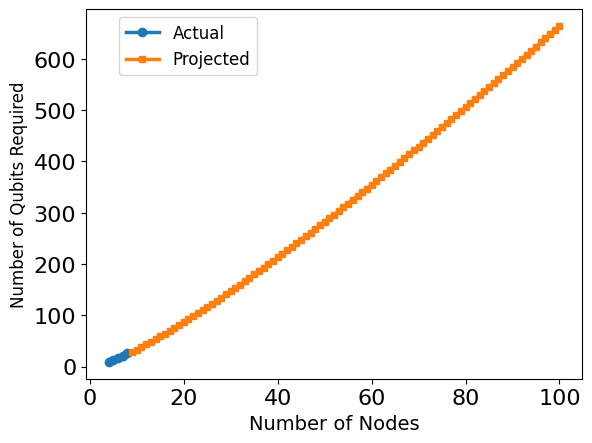

In [ ]:
# Plot 2 (Top Right): Qubit Requirements
x_known = np.array([4, 5, 6, 7, 8])
y_known_theo = x_known * np.log2(x_known)
y_known_act = np.array([4, 5, 6, 7, 8])

# Interpolation range
x_interp = np.arange(4, 9)
y_interp = np.interp(x_interp, x_known, y_known_theo)
y1_interp = np.abs(np.ceil(x_interp * np.log(y_interp)))

# Extrapolation range with quadratic projection (y = x^2)
x_extra = np.arange(9, 101)

y_extra = x_extra*np.log2(x_extra)
# y1_extra = np.abs(np.ceil(x_extra * np.log(y_extra)))

plt.plot(x_interp, y1_interp, 'o-', label="Actual", 
        color='#1f77b4', linewidth=2.5, markersize=6)
plt.plot(x_extra, y_extra, 's-', label="Projected", 
        color='#ff7f0e', linewidth=2.5, markersize=4)

plt.xlabel('Number of Nodes', fontsize=14)
plt.ylabel('Number of Qubits Required', fontsize=12)
plt.legend(loc='upper left', fontsize=12, bbox_to_anchor=(0.05, 1))
plt.tick_params(axis='both', which='major', labelsize=16)

plt.show()

In [67]:
import numpy as np
import pandas as pd

# sat_df = your dataframe

# Aggregate chromatic numbers per node count
df_chi = (
    sat_df.groupby('Nodes', as_index=False)['Chromatic_Exact']
          .mean()   # average chromatic number per n (smooths noisy ER graphs)
          .rename(columns={'Chromatic_Exact': 'Chromatic_mean'})
)

# Real qubits required: n * ceil(log2(χ(G)))
df_chi['Qubits_real'] = df_chi['Nodes'] * np.log2(df_chi['Chromatic_mean'])

# Worst-case qubits: n * ceil(log2(n))
df_chi['Qubits_worst'] = df_chi['Nodes'] * np.ceil(np.log2(df_chi['Nodes']))


In [68]:
# Projection range (e.g., up to 100 nodes)
n_min = int(df_chi['Nodes'].min())
n_max_data = int(df_chi['Nodes'].max())
n_proj_max = max(n_max_data, 100)

n_proj = np.arange(n_min, n_proj_max + 1)

# Worst-case projection: m = n
Q_worst_proj = n_proj * np.log2(n_proj)   # smooth worst-case

# Fit real qubits to the n*log2(n) model
x_feat = df_chi['Nodes'] * np.log2(df_chi['Nodes'])
y_real = df_chi['Qubits_real']

# Linear fit: Q ≈ a * (n log n) + b
a, b = np.polyfit(x_feat, y_real, 1)

# Generate projection curve
Q_real_proj = a * n_proj * np.log2(n_proj) + b


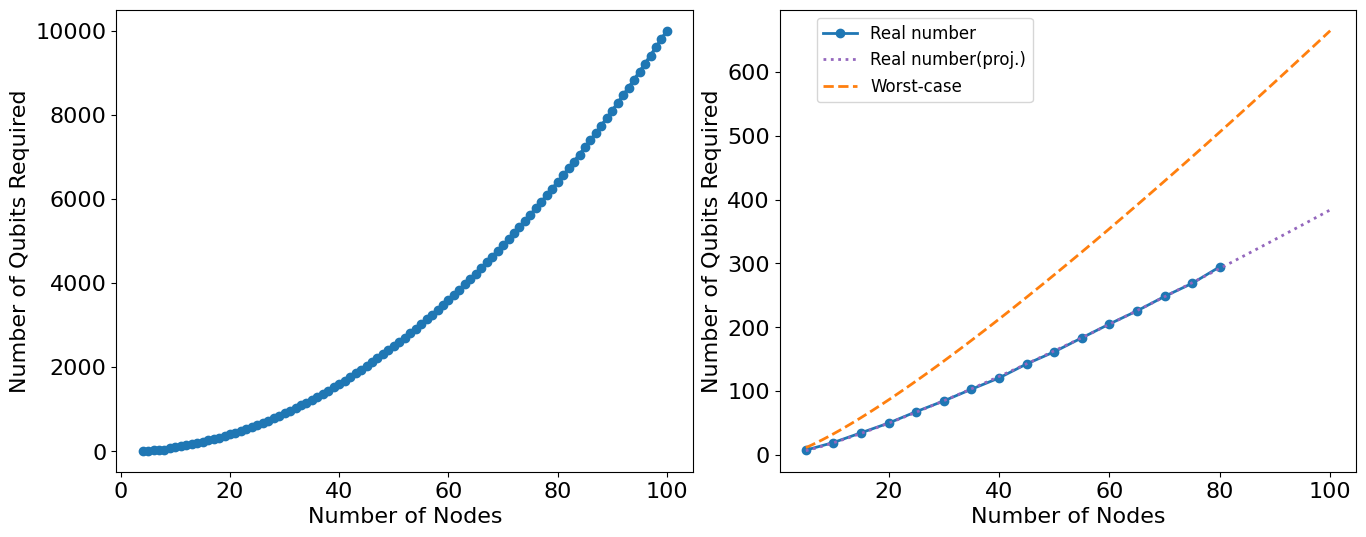

In [73]:
# Plot 2 (Top Right): Qubit Requirements
x_known = np.array([2, 3, 4, 5, 6, 7, 8])
y_known_theo = np.array([4, 9, 16, 25, 35, 47, 64])
y_known_act = np.array([])

# Interpolation range
x_interp = np.arange(4, 9)
y_interp = np.interp(x_interp, x_known, y_known_theo)
y1_interp = np.abs(np.ceil(x_interp * np.log(y_interp)))

# Extrapolation range with quadratic projection (y = x^2)
x_extra = np.arange(9, 101)
y_extra = x_extra ** 2
# y1_extra = np.abs(np.ceil(x_extra * np.log(y_extra)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.15)

ax1.plot(x_interp, y1_interp, 'o-', label="Actual", 
        color='#1f77b4', linewidth=2.5, markersize=6)
ax1.plot(x_extra, y_extra, 'o-', label="Projected", 
        color='#1f77b4', linewidth=2.5, markersize=6)

ax1.set_xlabel('Number of Nodes', fontsize=16)
ax1.set_ylabel('Number of Qubits Required', fontsize=16)
# plt.legend(loc='upper left', fontsize=12, bbox_to_anchor=(0.05, 1))
ax1.tick_params(axis='both', which='major', labelsize=16)

# plt.show()

# --- Qubit Requirements Subplot (ax3) ---

# Real qubits (actual from SAT chromatic numbers)
ax2.plot(
    df_chi['Nodes'], df_chi['Qubits_real'],
    marker='o', linestyle='-', linewidth=2,
    color='#1f77b4',
    label='Real number'
)

# Real qubit projection curve
ax2.plot(
    n_proj, Q_real_proj,
    linestyle=':', linewidth=2,
    color='#9467bd',
    label='Real number(proj.)'
)

# Worst-case projection curve
ax2.plot(
    n_proj, Q_worst_proj,
    linestyle='--', linewidth=2,
    color='#ff7f0e',
    label='Worst-case'
)

ax2.set_xlabel('Number of Nodes', fontsize=16)
ax2.set_ylabel('Number of Qubits Required', fontsize=16)
ax2.legend(loc='upper left', fontsize=12, bbox_to_anchor=(0.05, 1))
ax2.tick_params(axis='both', which='major', labelsize=16)
# ax3.text(
#     0.02, 0.95, '(c)',
#     transform=ax3.transAxes,
#     fontsize=14, fontweight='bold', verticalalignment='top'
# )
